# Ataxia Neuromotor Instability Detection

Ce notebook présente une solution complète pour détecter l’ataxie neuromotrice à partir de données de marche.  
Le projet s’inscrit dans le domaine du **Computer Vision**, car les données proviennent de vidéos de marche analysées avec **MediaPipe Pose** afin d’extraire les coordonnées articulaires, les angles et les caractéristiques spatio-temporelles.

Objectif principal : distinguer les séquences de marche normales des séquences présentant une instabilité ataxique.

## Plan du notebook

Le notebook suit le pipeline demandé pour la validation :

1. Compréhension du problème
2. Présentation du dataset
3. Prétraitement des données
4. Création des séquences temporelles
5. Modèle Deep Learning from scratch : LSTM Autoencoder
6. Entraînement du modèle
7. Évaluation et visualisation des performances
8. XAI avec SHAP
9. Deuxième approche : GAN + LSTM
10. Comparaison finale
11. Pretrained model : positionnement et amélioration future
12. Conclusion générale

## 1. Compréhension du problème

L’ataxie est un trouble neurologique qui provoque une mauvaise coordination des mouvements. Elle peut affecter la marche, l’équilibre, la posture et la stabilité des membres.

Dans ce projet, on exploite des séquences de marche pour identifier des comportements anormaux. L’idée est d’apprendre le comportement d’une marche normale, puis de détecter les séquences qui s’éloignent de ce comportement.

## 2. Imports et configuration

Cette partie contient les bibliothèques nécessaires pour :

- lire et manipuler les données ;
- normaliser les features ;
- construire les modèles Deep Learning ;
- évaluer les performances ;
- visualiser les résultats.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_10.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_20.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_4.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_6.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_5.csv
/kaggle/input/datasets/yasmineben

Imports & Configuration

In [2]:
# =========================
# Importation des bibliothèques
# =========================

import os                 # Gestion des fichiers et dossiers
import gc                 # Libération de mémoire
import glob               # Recherche de fichiers
import joblib             # Sauvegarde/chargement objets Python

import numpy as np        # Calcul numérique
import pandas as pd       # Manipulation des données tabulaires
import matplotlib.pyplot as plt   # Visualisation graphique

# =========================
# Outils Machine Learning
# =========================

from sklearn.preprocessing import StandardScaler      # Normalisation des données
from sklearn.model_selection import train_test_split  # Séparation train/test
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# =========================
# Bibliothèques Deep Learning
# =========================

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    LSTM,
    RepeatVector,
    TimeDistributed,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# =========================
# Reproductibilité des résultats
# =========================

# Fixer les graines aléatoires pour obtenir les mêmes résultats à chaque exécution
np.random.seed(42)
tf.random.set_seed(42)

# =========================
# Informations TensorFlow / GPU
# =========================

print("TensorFlow version:", tf.__version__)

# Vérification de la disponibilité du GPU
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

2026-04-28 22:09:01.967429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777414142.177905      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777414142.240935      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777414142.726497      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777414142.726543      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777414142.726546      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Présentation du dataset

Le dataset contient des données de marche extraites à partir de vidéos réelles. Les vidéos ont été traitées avec MediaPipe Pose pour produire des fichiers CSV contenant des features de mouvement.

Structure générale :

- dossier des sujets avec marche normale ;
- dossier des sujets avec marche ataxique ;
- environ 40 fichiers CSV ;
- 47 features décrivant les articulations, les angles et des mesures spatio-temporelles.

Même si le modèle final travaille sur des CSV, l’origine des données est visuelle : c’est donc bien une approche liée au **Computer Vision**.

In [3]:
# =========================
# Définition des chemins du dataset
# =========================

# Chemin principal du dataset
DATASET_PATH = (
    "/kaggle/input/datasets/yasminebenjouida/ataxia/"
    "Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose"
)

# Dossier contenant les données de marche normale
NORMAL_PATH = os.path.join(
    DATASET_PATH,
    "Normal Gait",
    "normal_features"
)

# Dossier contenant les données de marche ataxique
ATAXIC_PATH = os.path.join(
    DATASET_PATH,
    "Cerebellar Ataxic Gait",
    "ataxia_features"
)

# =========================
# Chargement des fichiers CSV
# =========================

# Récupération de tous les fichiers CSV normaux
normal_files = sorted(glob.glob(NORMAL_PATH + "/*.csv"))

# Récupération de tous les fichiers CSV ataxiques
ataxic_files = sorted(glob.glob(ATAXIC_PATH + "/*.csv"))

# =========================
# Affichage du nombre de fichiers
# =========================

print(f"Fichiers normaux  : {len(normal_files)}")
print(f"Fichiers ataxiques: {len(ataxic_files)}")

Fichiers normaux  : 20
Fichiers ataxiques: 20


## 4. Prétraitement des données

Le prétraitement transforme les fichiers CSV en données exploitables par le modèle. Les étapes principales sont :

- lecture des fichiers CSV ;
- conservation des colonnes numériques ;
- gestion des valeurs manquantes ;
- transformation des données en séquences temporelles ;
- normalisation avec StandardScaler.

La normalisation est ajustée uniquement sur les données normales afin que le modèle apprenne d’abord la distribution d’une marche saine.

In [4]:
# =========================
# Fonction de lecture des fichiers CSV
# =========================

def read_file(file_path):

    """
    Cette fonction permet de :

    - lire un fichier CSV
    - conserver uniquement les colonnes numériques
    - gérer les valeurs manquantes (NaN)

    Les données utilisées correspondent aux features extraites
    à partir des vidéos de marche via MediaPipe Pose.
    """

    try:
        # Lecture standard du fichier CSV
        df = pd.read_csv(file_path)

    except Exception:

        # Si erreur de séparateur, utiliser détection automatique
        df = pd.read_csv(file_path, sep=None, engine="python")

    # Conservation uniquement des colonnes numériques
    df = df.select_dtypes(include=[np.number])

    # Gestion des valeurs manquantes :
    # ffill = propagation avant
    # bfill = propagation arrière
    # fillna(0) = remplacement final par 0
    df = df.ffill().bfill().fillna(0)

    return df

# =========================
# Vérification du chargement
# =========================

# Lecture d’un exemple de fichier normal
sample = read_file(normal_files[0])

# Affichage dimensions du fichier
print("Shape sample normal:", sample.shape)

# Affichage des premières lignes
sample.head()

Shape sample normal: (45441, 47)


,XLeftShoulder,YLeftShoulder,ZLeftShoulder,XRightShoulder,YRightShoulder,ZRightShoulder,XLeftElbow,YLeftElbow,ZLeftElbow,XRightElbow,...,ThetaRightShoulder,ThetaLeftHip,ThetaRightHip,ThetaLeftKnee,ThetaRightKnee,StepLength,StepWidth,FeetClearance,LeftStrideSpeed,RightStrideSpeed
0,-0.196502,-0.196502,-0.196502,0.126889,0.126889,0.126889,-0.263015,-0.263015,-0.263015,0.210626,...,2.792959,0.808892,2.796997,0.267965,0.203338,0.134997,0.228526,0.083788,16.474430,15.856428
1,-0.192490,-0.192490,-0.192490,0.124677,0.124677,0.124677,-0.253214,-0.253214,-0.253214,0.197687,...,2.786324,0.785949,2.809310,0.274411,0.209789,0.111689,0.232293,0.076326,16.469497,15.964976
2,-0.189622,-0.189622,-0.189622,0.123115,0.123115,0.123115,-0.248308,-0.248308,-0.248308,0.190342,...,2.784061,0.794110,2.805572,0.274392,0.225385,0.115111,0.231483,0.072137,16.432931,15.986685
3,-0.187383,-0.187383,-0.187383,0.122791,0.122791,0.122791,-0.244551,-0.244551,-0.244551,0.187892,...,2.783975,0.779831,2.804275,0.278168,0.213683,0.102136,0.231394,0.068088,16.467296,16.074071
4,-0.184411,-0.184411,-0.184411,0.122877,0.122877,0.122877,-0.242397,-0.242397,-0.242397,0.188848,...,2.787074,0.776580,2.814312,0.272495,0.197828,0.122620,0.229627,0.068949,16.475757,16.179002


### Création des séquences temporelles

Les données de marche sont temporelles. Une seule ligne du CSV ne suffit pas pour comprendre le mouvement.  
On utilise donc une fenêtre glissante pour créer des séquences de plusieurs timesteps. Cela permet au LSTM d’apprendre l’évolution du mouvement dans le temps.

In [5]:
# =========================
# Paramètres des séquences temporelles
# =========================

# Nombre de frames/timestamps dans chaque séquence
WINDOW_SIZE = 60

# Pas de déplacement entre deux fenêtres
STEP = 10

# =========================
# Fonction de création des séquences
# =========================

def create_sequences(data, window_size=WINDOW_SIZE, step=STEP):

    """
    Cette fonction transforme les données temporelles
    en séquences exploitables par les modèles LSTM.

    Principe :
    - une fenêtre glissante parcourt les données
    - chaque fenêtre contient 60 timestamps
    - le déplacement entre deux fenêtres est de 10

    Les séquences créées représentent les mouvements
    de marche sur une période donnée.
    """

    sequences = []

    # Parcours des données avec fenêtre glissante
    for start in range(0, len(data) - window_size, step):

        # Extraction d’une séquence
        sequences.append(
            data[start:start + window_size]
        )

    # Conversion en tableau numpy
    return np.array(sequences)

## Computer Vision avec MediaPipe Pose

Dans cette étape, nous utilisons MediaPipe Pose afin de détecter les articulations du corps humain à partir d’une vidéo de marche.

Cette étape représente la partie Computer Vision du projet.
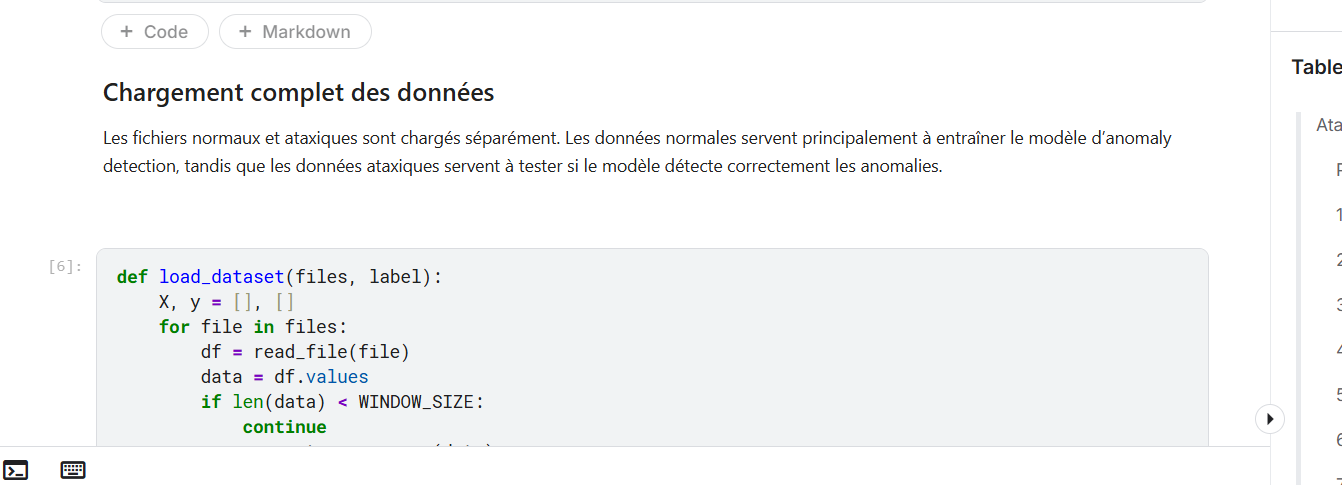

In [5]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.13 opencv-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 33.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 22.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4

In [3]:
# =========================
# Installation des bibliothèques Computer Vision
# =========================

# MediaPipe : détection des articulations du corps humain
# OpenCV : traitement des images et vidéos

!pip install mediapipe==0.10.13 opencv-python -q

# =========================
# Importation des bibliothèques
# =========================

import cv2                    # Traitement image/vidéo
import mediapipe as mp        # Computer Vision / Pose Estimation
import matplotlib.pyplot as plt   # Affichage graphique

# =========================
# Vérification installation MediaPipe
# =========================

# Affichage version MediaPipe
print(mp.__version__)

# Vérification disponibilité du module "solutions"
print(hasattr(mp, "solutions"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 41.6 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 22.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 

2026-05-05 20:27:08.754892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778012828.959543      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778012829.021765      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778012829.526321      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778012829.526370      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778012829.526374      57 computation_placer.cc:177] computation placer alr

0.10.13
True


In [6]:
# =========================
# Exploration des fichiers du dataset
# =========================

# Cette cellule permet d’afficher tous les fichiers
# présents dans le dossier Kaggle Input.

# Elle est utile pour :
# - vérifier le chargement des données
# - récupérer les chemins exacts des fichiers
# - localiser les vidéos et fichiers CSV

import os

# Parcours de tous les dossiers et fichiers
for dirname, _, filenames in os.walk('/kaggle/input'):

    for filename in filenames:

        # Affichage du chemin complet du fichier
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yasminebenjouida/gait-video-mp4/Recording 2026-05-05 220821.mp4
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_10.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_20.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_4.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe Pose/Normal Gait/normal_features/normal_features_6.csv
/kaggle/input/datasets/yasminebenjouida/ataxia/Dataset for Gait Analysis of Cerebellar Ataxic Patients and Healthy Adults Using MediaPipe P

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Pose détectée avec succès


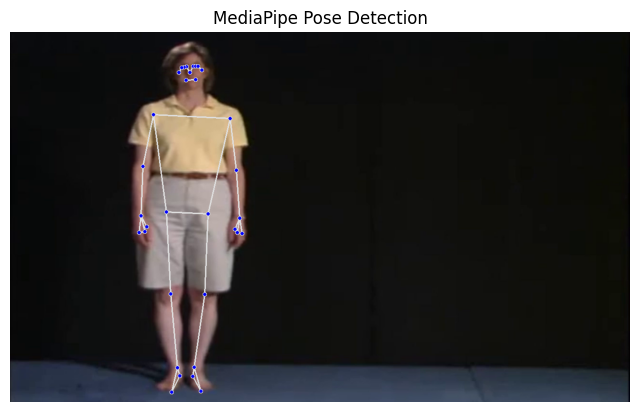

In [7]:
# =========================
# Computer Vision avec MediaPipe Pose
# =========================

# Cette étape permet d’analyser une vidéo de marche
# afin de détecter automatiquement les articulations
# du corps humain.

# MediaPipe Pose représente la partie
# Computer Vision du projet.

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

# =========================
# Chemin exact de la vidéo
# =========================

video_path = "/kaggle/input/datasets/yasminebenjouida/gait-video-mp4/Recording 2026-05-05 220821.mp4"

# =========================
# Initialisation MediaPipe
# =========================

# Module de détection de pose
mp_pose = mp.solutions.pose

# Module de dessin du squelette
mp_drawing = mp.solutions.drawing_utils

# =========================
# Lecture de la vidéo
# =========================

cap = cv2.VideoCapture(video_path)

# Vérification ouverture vidéo
if not cap.isOpened():

    print("Erreur : impossible d'ouvrir la vidéo")

else:

    # =========================
    # Initialisation du modèle Pose
    # =========================

    pose = mp_pose.Pose(

        # Mode vidéo
        static_image_mode=False,

        # Complexité du modèle
        model_complexity=1,

        # Désactivation segmentation
        enable_segmentation=False,

        # Confiance minimale détection
        min_detection_confidence=0.5,

        # Confiance minimale tracking
        min_tracking_confidence=0.5
    )

    # =========================
    # Lecture d’une frame vidéo
    # =========================

    # Lecture de la première frame
    success, frame = cap.read()

    # Vérification lecture frame
    if not success:

        print("Erreur : impossible de lire la frame")

    else:

        # =========================
        # Conversion couleur BGR → RGB
        # =========================

        # OpenCV utilise BGR par défaut
        # MediaPipe utilise RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # =========================
        # Détection de pose
        # =========================

        # Analyse de la frame par MediaPipe
        results = pose.process(frame_rgb)

        # Copie de l’image originale
        annotated_frame = frame_rgb.copy()

        # =========================
        # Dessin du squelette humain
        # =========================

        if results.pose_landmarks:

            # Dessin des articulations et connexions
            mp_drawing.draw_landmarks(
                annotated_frame,
                results.pose_landmarks,
                mp_pose.POSE_CONNECTIONS
            )

            print("Pose détectée avec succès")

        else:

            print("Aucune pose détectée")

        # =========================
        # Affichage du résultat
        # =========================

        plt.figure(figsize=(8,8))

        # Affichage image annotée
        plt.imshow(annotated_frame)

        # Suppression axes
        plt.axis("off")

        # Titre image
        plt.title("MediaPipe Pose Detection")

        plt.show()

# =========================
# Libération mémoire
# =========================

cap.release()

## Résultat de la détection de pose

Cette étape montre l’utilisation du Computer Vision avec MediaPipe Pose pour détecter automatiquement les articulations du corps humain à partir d’une vidéo de marche.

Les données utilisées dans notre dataset principal sont obtenues à partir du même principe d’extraction.

### Chargement complet des données

Les fichiers normaux et ataxiques sont chargés séparément. Les données normales servent principalement à entraîner le modèle d’anomaly detection, tandis que les données ataxiques servent à tester si le modèle détecte correctement les anomalies.

In [6]:
# =========================
# Fonction de chargement du dataset
# =========================

def load_dataset(files, label):

    """
    Cette fonction permet de :

    - charger tous les fichiers CSV
    - transformer les données en séquences temporelles
    - attribuer les labels correspondants

    Labels :
    0 = marche normale
    1 = marche ataxique
    """

    X, y = [], []

    # Parcours de tous les fichiers
    for file in files:

        # Lecture du fichier CSV
        df = read_file(file)

        # Conversion dataframe → numpy array
        data = df.values

        # Ignorer fichiers trop petits
        if len(data) < WINDOW_SIZE:
            continue

        # Création des séquences temporelles
        seq = create_sequences(data)

        # Vérification présence séquences
        if len(seq) > 0:

            # Ajout des séquences
            X.append(seq)

            # Ajout des labels correspondants
            y.extend([label] * len(seq))

    # Fusion de toutes les séquences
    return np.concatenate(X, axis=0), np.array(y)

# =========================
# Chargement des données normales
# =========================

X_normal, y_normal = load_dataset(
    normal_files,
    label=0
)

# =========================
# Chargement des données ataxiques
# =========================

X_ataxic, y_ataxic = load_dataset(
    ataxic_files,
    label=1
)

# =========================
# Affichage dimensions des données
# =========================

print("X_normal :", X_normal.shape)
print("X_ataxic :", X_ataxic.shape)

X_normal : (93967, 60, 47)
X_ataxic : (159696, 60, 47)


### Normalisation

Le StandardScaler est entraîné sur les données normales uniquement.  
Cette stratégie est cohérente avec l’approche d’anomaly detection : le modèle apprend ce qui est normal, puis considère comme suspect ce qui s’en éloigne.

In [7]:
# =========================
# Dimensions des séquences
# =========================

# Nombre de timestamps dans chaque séquence
n_timesteps = X_normal.shape[1]

# Nombre de features biomécaniques
n_features = X_normal.shape[2]

# Affichage dimensions
print(f"Timesteps: {n_timesteps} | Features: {n_features}")

# =========================
# Normalisation des données
# =========================

# StandardScaler :
# moyenne = 0
# écart-type = 1

# La normalisation améliore :
# - la stabilité du modèle
# - la vitesse d’apprentissage
# - les performances du réseau LSTM

scaler = StandardScaler()

# Reshape temporaire pour appliquer StandardScaler
scaler.fit(
    X_normal.reshape(-1, n_features)
)

# =========================
# Fonction de normalisation
# =========================

def scale_sequences(X):

    """
    Cette fonction applique la normalisation
    sur les séquences temporelles.
    """

    return scaler.transform(
        X.reshape(-1, n_features)
    ).reshape(X.shape)

# =========================
# Normalisation données normales
# =========================

X_normal_scaled = scale_sequences(X_normal)

# =========================
# Normalisation données ataxiques
# =========================

X_ataxic_scaled = scale_sequences(X_ataxic)

# =========================
# Vérification dimensions
# =========================

print("Normal scaled :", X_normal_scaled.shape)
print("Ataxic scaled :", X_ataxic_scaled.shape)

Timesteps: 60 | Features: 47
Normal scaled : (93967, 60, 47)
Ataxic scaled : (159696, 60, 47)


### Séparation entraînement / validation

Les séquences normales sont divisées en deux parties :

- Train : pour entraîner le modèle ;
- Validation : pour vérifier la reconstruction sur des données normales non vues pendant l’entraînement.

In [8]:
# =========================
# Séparation Train / Validation
# =========================

# Les données normales sont divisées en :
# - ensemble d’entraînement (Train)
# - ensemble de validation (Validation)

# Cette étape permet :
# - d’entraîner le modèle
# - d’évaluer ses performances
# - d’éviter le surapprentissage (Overfitting)

X_train, X_val = train_test_split(

    # Données normales normalisées
    X_normal_scaled,

    # 20% des données pour validation
    test_size=0.2,

    # Reproductibilité
    random_state=42,

    # Mélange aléatoire des données
    shuffle=True
)

# =========================
# Affichage dimensions
# =========================

print("Train :", X_train.shape)
print("Val   :", X_val.shape)

Train : (75173, 60, 47)
Val   : (18794, 60, 47)


Architecture LSTM Autoencoder

## 5. Modèle Deep Learning from scratch : LSTM Autoencoder

Dans ce projet, le modèle principal est entraîné **from scratch**, c’est-à-dire construit et appris directement sur notre dataset.

Pourquoi LSTM ?  
Les données représentent une marche dans le temps. Le LSTM est adapté aux séries temporelles car il peut apprendre les dépendances entre les timesteps.

Pourquoi Autoencoder ?  
L’autoencoder apprend à reconstruire une séquence normale. Si une séquence est ataxique, la reconstruction devient moins précise et l’erreur augmente.

Principe :

- faible erreur de reconstruction → séquence normale ;
- erreur élevée → séquence anormale / ataxique.

In [9]:
# =========================
# Construction du modèle LSTM Autoencoder
# =========================

def build_autoencoder(n_timesteps, n_features):

    """
    Ce modèle Autoencoder permet :

    - d’apprendre les patterns normaux de marche
    - de reconstruire les séquences normales
    - de détecter les anomalies de marche

    Principe :
    - faible erreur reconstruction → marche normale
    - forte erreur reconstruction → marche anormale
    """

    # =========================
    # Entrée du modèle
    # =========================

    inp = Input(
        shape=(n_timesteps, n_features)
    )

    # =========================
    # Encoder
    # =========================

    # Première couche LSTM
    x = LSTM(
        128,
        return_sequences=True
    )(inp)

    # Dropout pour réduire l’overfitting
    x = Dropout(0.2)(x)

    # Compression des informations
    x = LSTM(
        64,
        return_sequences=False
    )(x)

    # =========================
    # Bottleneck → Decoder
    # =========================

    # Répétition du vecteur latent
    x = RepeatVector(n_timesteps)(x)

    # Reconstruction séquence
    x = LSTM(
        64,
        return_sequences=True
    )(x)

    # Réduction overfitting
    x = Dropout(0.2)(x)

    # Reconstruction finale
    x = LSTM(
        128,
        return_sequences=True
    )(x)

    # =========================
    # Sortie du modèle
    # =========================

    out = TimeDistributed(
        Dense(n_features)
    )(x)

    # =========================
    # Création modèle
    # =========================

    model = Model(inp, out)

    # Compilation modèle
    model.compile(

        # Optimiseur Adam
        optimizer="adam",

        # Fonction perte :
        # erreur quadratique moyenne
        loss="mse"
    )

    return model

# =========================
# Initialisation du modèle
# =========================

autoencoder = build_autoencoder(
    n_timesteps,
    n_features
)

# =========================
# Résumé architecture modèle
# =========================

autoencoder.summary()

I0000 00:00:1777414214.528199      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 47)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 128)        │        90,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 60, 47)         │         6,063 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,423 (1.06 MB)

 Trainable params: 277,423 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entraînement du modèle

Le modèle est entraîné sur les séquences normales. L’objectif est de minimiser l’erreur de reconstruction entre la séquence originale et la séquence reconstruite.

Les callbacks utilisés permettent :

- d’arrêter l’entraînement si la validation ne s’améliore plus ;
- de sauvegarder automatiquement le meilleur modèle.

In [10]:
# =========================
# Callbacks d’entraînement
# =========================

callbacks = [

    # EarlyStopping :
    # arrêt automatique si la loss validation
    # ne s’améliore plus pendant 5 epochs

    EarlyStopping(

        # Surveillance de la validation loss
        monitor="val_loss",

        # Nombre d’epochs avant arrêt
        patience=5,

        # Restaurer meilleurs poids
        restore_best_weights=True,

        verbose=1
    ),

    # Sauvegarde du meilleur modèle
    ModelCheckpoint(

        # Nom du fichier modèle
        "best_autoencoder.keras",

        # Surveillance validation loss
        monitor="val_loss",

        # Sauvegarder uniquement meilleur modèle
        save_best_only=True,

        verbose=0
    )
]

# =========================
# Entraînement du modèle
# =========================

history = autoencoder.fit(

    # Entrée : données normales
    X_train,

    # Sortie cible :
    # reconstruction des mêmes données
    X_train,

    # Nombre maximal d’epochs
    epochs=50,

    # Taille des batches
    batch_size=32,

    # Données validation
    validation_data=(X_val, X_val),

    # Callbacks
    callbacks=callbacks,

    # Mélange aléatoire des données
    shuffle=True,

    verbose=1
)

Epoch 1/50


I0000 00:00:1777414225.639578     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


2350/2350 ━━━━━━━━━━━━━━━━━━━━ 59s 22ms/step - loss: 0.2879 - val_loss: 0.1887
Epoch 2/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1810 - val_loss: 0.1591
Epoch 3/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1577 - val_loss: 0.1393
Epoch 4/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1414 - val_loss: 0.1338
Epoch 5/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1320 - val_loss: 0.1238
Epoch 6/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 49s 21ms/step - loss: 0.1306 - val_loss: 0.1173
Epoch 7/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1209 - val_loss: 0.1162
Epoch 8/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 49s 21ms/step - loss: 0.1174 - val_loss: 0.1128
Epoch 9/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1142 - val_loss: 0.1084
Epoch 10/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1109 - val_loss: 0.1059
Epoch 11/50
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 0.1097 - val_loss: 0.1035
Epoch 12/50
2350/23

### Sauvegarde du modèle

La sauvegarde du modèle et du scaler permet de réutiliser le système plus tard sans réentraîner le modèle. Ces fichiers peuvent ensuite être intégrés dans une API ou une application.

In [11]:
# =========================
# Sauvegarde du modèle et du scaler
# =========================

# Sauvegarde immédiate afin d’éviter
# la perte du travail en cas de :
# - erreur mémoire (OOM)
# - interruption du notebook
# - crash de session Kaggle

# =========================
# Sauvegarde du modèle Autoencoder
# =========================

autoencoder.save(
    "lstm_autoencoder_ataxia.keras"
)

# =========================
# Sauvegarde du scaler
# =========================

joblib.dump(
    scaler,
    "scaler_ataxia.pkl"
)

# =========================
# Confirmation sauvegarde
# =========================

print("✅ Modèle sauvegardé : lstm_autoencoder_ataxia.keras")

print("✅ Scaler sauvegardé : scaler_ataxia.pkl")

✅ Modèle sauvegardé : lstm_autoencoder_ataxia.keras
✅ Scaler sauvegardé : scaler_ataxia.pkl


### Courbe d’entraînement

La courbe de loss permet de vérifier si le modèle apprend correctement. Une loss qui diminue indique que le modèle améliore sa capacité de reconstruction.

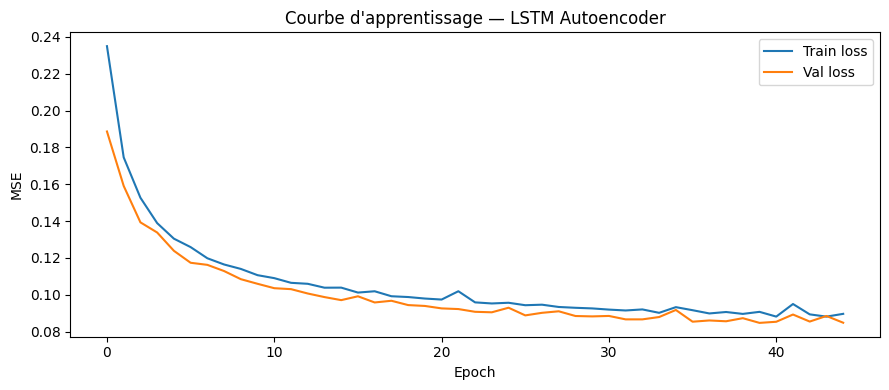

In [12]:
# =========================
# Visualisation des performances du modèle
# =========================

# Cette courbe permet d’observer :
# - l’évolution de la loss d’entraînement
# - l’évolution de la loss validation
# - la qualité de l’apprentissage du modèle

# Une diminution progressive de la loss
# indique que le modèle apprend correctement
# les patterns normaux de marche.

plt.figure(figsize=(9, 4))

# Courbe perte entraînement
plt.plot(
    history.history["loss"],
    label="Train loss"
)

# Courbe perte validation
plt.plot(
    history.history["val_loss"],
    label="Val loss"
)

# Axe X
plt.xlabel("Epoch")

# Axe Y
plt.ylabel("MSE")

# Titre graphique
plt.title("Courbe d'apprentissage — LSTM Autoencoder")

# Affichage légende
plt.legend()

# Ajustement affichage
plt.tight_layout()

# Affichage graphique
plt.show()

## Interprétation des résultats du LSTM Autoencoder

Cette courbe représente l’évolution de la fonction de perte (MSE) durant l’entraînement du modèle LSTM Autoencoder.

La courbe bleue correspond à la perte sur les données d’entraînement (Train loss), tandis que la courbe orange représente la perte sur les données de validation (Validation loss).

On observe une diminution progressive des deux courbes au fil des epochs, ce qui indique que le modèle apprend correctement les patterns de marche normale.

La proximité entre les courbes Train et Validation montre également que le modèle généralise correctement sans phénomène important d’overfitting.

À la fin de l’entraînement, les valeurs de perte deviennent faibles et stables, ce qui signifie que le modèle parvient à reconstruire efficacement les séquences normales de marche.

Les résultats obtenus sont satisfaisants, car le modèle présente un apprentissage stable ainsi qu’une bonne capacité de généralisation sur les données de validation.

Ainsi, le modèle peut ensuite détecter les anomalies de marche ataxique grâce à l’erreur de reconstruction :
- faible erreur → marche normale
- forte erreur → marche anormale / ataxique

## 7. Évaluation du LSTM Autoencoder

L’évaluation repose sur l’erreur de reconstruction. On calcule cette erreur pour les séquences normales et ataxiques, puis on choisit un seuil d’anomalie.

Si l’erreur d’une séquence dépasse ce seuil, elle est considérée comme ataxique.

In [13]:
# =========================
# Calcul de l’erreur de reconstruction
# =========================

def reconstruction_error(model, X, batch_size=16, chunk_size=500):

    """
    Cette fonction calcule l’erreur de reconstruction
    séquence par séquence.

    Principe :
    - le modèle reconstruit les séquences d’entrée
    - on compare les données originales et reconstruites
    - plus l’erreur est élevée, plus la séquence est anormale

    Paramètres :
    - batch_size : limite la consommation mémoire
    - chunk_size : traitement par morceaux pour éviter OOM
    """

    all_errors = []

    # Traitement des données par morceaux
    for i in range(0, len(X), chunk_size):

        # Extraction d’un chunk
        chunk = X[i:i + chunk_size]

        # Reconstruction des séquences
        preds = model.predict(
            chunk,
            batch_size=batch_size,
            verbose=0
        )

        # Calcul erreur quadratique moyenne
        errors = np.mean(
            np.square(chunk - preds),
            axis=(1, 2)
        )

        # Stockage des erreurs
        all_errors.extend(errors)

        # Libération mémoire RAM
        gc.collect()

    return np.array(all_errors)

# =========================
# Calcul erreurs données normales train
# =========================

print("Calcul erreurs train...")

train_errors = reconstruction_error(
    autoencoder,
    X_train
)

gc.collect()

# =========================
# Calcul erreurs validation
# =========================

print("Calcul erreurs val...")

val_errors = reconstruction_error(
    autoencoder,
    X_val
)

gc.collect()

# =========================
# Calcul erreurs données ataxiques
# =========================

print("Calcul erreurs ataxie...")

ataxic_errors = reconstruction_error(
    autoencoder,
    X_ataxic_scaled
)

gc.collect()

# =========================
# Affichage erreurs moyennes
# =========================

print(f"\nErreur moyenne Normal : {np.mean(val_errors):.4f}")

print(f"Erreur moyenne Ataxie : {np.mean(ataxic_errors):.4f}")

Calcul erreurs train...
Calcul erreurs val...
Calcul erreurs ataxie...

Erreur moyenne Normal : 0.0847
Erreur moyenne Ataxie : 0.5238


### Seuil d’anomalie

Le seuil est défini à partir des erreurs obtenues sur les données normales d’entraînement. Ici, on utilise le percentile 95 : les séquences ayant une erreur supérieure à ce seuil sont considérées comme anomalies.

In [14]:
# =========================
# Définition du seuil d’anomalie
# =========================

# Le seuil d’anomalie est calculé à partir
# des erreurs de reconstruction des données normales.

# Utilisation du percentile 95 :
# - 95% des données normales sont considérées normales
# - les erreurs supérieures au seuil sont considérées anormales

# Ce seuil permet de distinguer :
# - marche normale
# - marche ataxique / anormale

threshold = np.percentile(
    train_errors,
    95
)

# =========================
# Affichage du seuil
# =========================

print(f"Seuil d'anomalie (percentile 95) : {threshold:.6f}")

Seuil d'anomalie (percentile 95) : 0.189902


### Classification Normal / Ataxie

Les séquences normales de validation et les séquences ataxiques sont regroupées pour tester la capacité du modèle à distinguer les deux classes.

In [15]:
# =========================
# Construction du dataset de test
# =========================

# Fusion des données :
# - validation normale
# - données ataxiques

# Ce dataset permettra d’évaluer
# la capacité du modèle à détecter
# les anomalies de marche.

X_test = np.concatenate(
    [X_val, X_ataxic_scaled],
    axis=0
)

# =========================
# Création des labels
# =========================

# 0 = Normal
# 1 = Ataxie

y_test = np.concatenate([
    np.zeros(len(X_val)),
    np.ones(len(X_ataxic_scaled))
])

# =========================
# Calcul des erreurs de reconstruction
# =========================

print("Calcul erreurs test...")

test_errors = reconstruction_error(
    autoencoder,
    X_test
)

gc.collect()

# =========================
# Prédictions finales
# =========================

# Si erreur > seuil :
# → anomalie détectée

y_pred = (
    test_errors > threshold
).astype(int)

# =========================
# Évaluation des performances
# =========================

print("\n─── Résultats ───────────────────────────────")

# Accuracy globale
print(
    f"Accuracy : {accuracy_score(y_test, y_pred):.4f}"
)

# Matrice de confusion
print("\nMatrice de confusion:")

print(
    confusion_matrix(y_test, y_pred)
)

# Rapport détaillé :
# précision, recall, f1-score
print("\nRapport de classification:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Ataxie"]
    )
)

Calcul erreurs test...

─── Résultats ───────────────────────────────
Accuracy : 0.8693

Matrice de confusion:
[[ 17828    966]
 [ 22366 137330]]

Rapport de classification:
              precision    recall  f1-score   support

      Normal       0.44      0.95      0.60     18794
      Ataxie       0.99      0.86      0.92    159696

    accuracy                           0.87    178490
   macro avg       0.72      0.90      0.76    178490
weighted avg       0.94      0.87      0.89    178490



### Visualisation des erreurs

La distribution des erreurs permet de voir si les séquences ataxiques ont tendance à produire une erreur plus élevée que les séquences normales. Cette séparation est importante pour valider l’approche.

/tmp/ipykernel_57/367152553.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([val_errors, ataxic_errors], labels=["Normal", "Ataxie"], patch_artist=True,


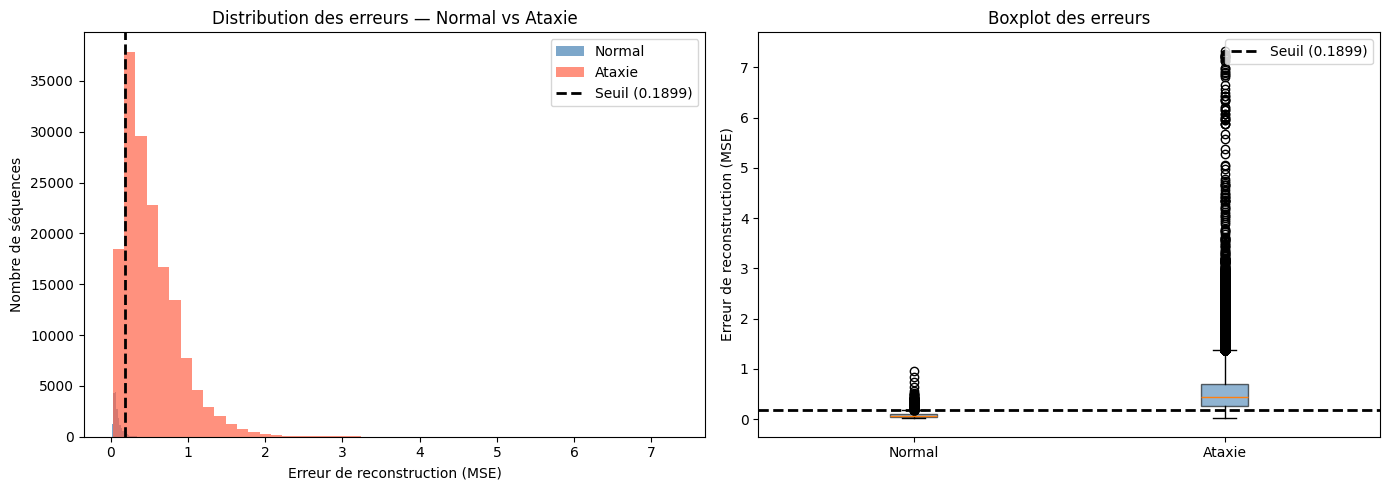

In [16]:
# =========================
# Visualisation des erreurs de reconstruction
# =========================

# Cette visualisation permet de comparer :
# - les erreurs des séquences normales
# - les erreurs des séquences ataxiques

# Un modèle efficace doit produire :
# - faibles erreurs pour les données normales
# - fortes erreurs pour les données anormales

# =========================
# Création de la figure
# =========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# =========================================================
# Histogramme des erreurs : Normal vs Ataxie
# =========================================================

# Distribution erreurs normales
axes[0].hist(
    val_errors,
    bins=50,
    alpha=0.7,
    color="steelblue",
    label="Normal"
)

# Distribution erreurs ataxiques
axes[0].hist(
    ataxic_errors,
    bins=50,
    alpha=0.7,
    color="tomato",
    label="Ataxie"
)

# Affichage seuil anomalie
axes[0].axvline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Seuil ({threshold:.4f})"
)

# Labels axes
axes[0].set_xlabel(
    "Erreur de reconstruction (MSE)"
)

axes[0].set_ylabel(
    "Nombre de séquences"
)

# Titre graphique
axes[0].set_title(
    "Distribution des erreurs — Normal vs Ataxie"
)

# Affichage légende
axes[0].legend()

# =========================================================
# Boxplot des erreurs
# =========================================================

axes[1].boxplot(

    [val_errors, ataxic_errors],

    labels=["Normal", "Ataxie"],

    patch_artist=True,

    boxprops=dict(
        facecolor="steelblue",
        alpha=0.6
    )
)

# Affichage seuil anomalie
axes[1].axhline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Seuil ({threshold:.4f})"
)

# Axe Y
axes[1].set_ylabel(
    "Erreur de reconstruction (MSE)"
)

# Titre graphique
axes[1].set_title(
    "Boxplot des erreurs"
)

# Affichage légende
axes[1].legend()

# Ajustement affichage
plt.tight_layout()

# Affichage final
plt.show()

### Prédiction sur un nouveau fichier

Cette fonction permet d’utiliser le modèle sur un nouveau fichier CSV. Elle applique les mêmes étapes : lecture, création des séquences, normalisation, calcul de l’erreur et prédiction finale.

In [17]:
# =========================
# Fonction de prédiction finale
# =========================

def predict_gait(file_path):

    """
    Cette fonction permet de prédire
    si une démarche est :

    - normale
    - ataxique / anormale

    à partir d’un fichier CSV.

    Principe :
    - lecture des données
    - création des séquences
    - normalisation
    - calcul erreur reconstruction
    - comparaison avec le seuil anomalie
    """

    # =========================
    # Lecture du fichier CSV
    # =========================

    df = read_file(file_path)

    # Conversion dataframe → numpy
    data = df.values

    # =========================
    # Vérification taille minimale
    # =========================

    if len(data) < WINDOW_SIZE:

        return "Fichier trop court", None

    # =========================
    # Création des séquences
    # =========================

    seq = create_sequences(data)

    # =========================
    # Normalisation des séquences
    # =========================

    seq_scaled = scale_sequences(seq)

    # =========================
    # Calcul erreurs reconstruction
    # =========================

    errors = reconstruction_error(
        autoencoder,
        seq_scaled
    )

    # Erreur moyenne globale
    mean_error = float(
        np.mean(errors)
    )

    # =========================
    # Décision finale
    # =========================

    # Si erreur > seuil :
    # anomalie détectée

    result = (
        "⚠️  Anormal / Ataxie probable"
        if mean_error > threshold
        else "✅ Normal"
    )

    return result, mean_error

# =========================================================
# Test sur un fichier normal
# =========================================================

result, err = predict_gait(
    normal_files[0]
)

print(
    f"[Fichier normal]  → {result}  (erreur: {err:.4f})"
)

# =========================================================
# Test sur un fichier ataxique
# =========================================================

result, err = predict_gait(
    ataxic_files[0]
)

print(
    f"[Fichier ataxie]  → {result}  (erreur: {err:.4f})"
)

[Fichier normal]  → ✅ Normal  (erreur: 0.0787)
[Fichier ataxie]  → ✅ Normal  (erreur: 0.1707)


## 8. Explainable AI (XAI) avec SHAP

L’objectif de l’XAI est d’expliquer pourquoi le modèle considère certaines séquences comme normales ou ataxiques.

SHAP permet d’identifier les features qui influencent le plus le score d’anomalie. Cette étape est importante dans un contexte médical, car elle rend le modèle plus compréhensible et plus crédible.

In [18]:
# =========================
# Installation et importation de SHAP
# =========================

# SHAP (SHapley Additive exPlanations)
# est une méthode d’Explainable AI (XAI).

# Son objectif :
# expliquer les décisions prises
# par le modèle d’intelligence artificielle.

# Dans ce projet, SHAP permet :
# - d’identifier les features importantes
# - de comprendre les anomalies détectées
# - d’améliorer l’interprétabilité médicale

# Installation si nécessaire
# (déjà disponible sur Kaggle dans la plupart des cas)

# !pip install shap -q

# =========================
# Importation bibliothèque SHAP
# =========================

import shap

# Gestion des warnings
import warnings

warnings.filterwarnings("ignore")

# =========================
# Vérification version SHAP
# =========================

print("SHAP version:", shap.__version__)

SHAP version: 0.50.0


### Fonction wrapper pour SHAP

Comme le modèle est un autoencoder, il ne retourne pas directement une classe. On utilise donc une fonction qui retourne l’erreur MSE de reconstruction. SHAP explique ensuite quelles features contribuent le plus à cette erreur.

In [19]:
# =========================
# Fonction Wrapper pour SHAP
# =========================

def autoencoder_mse_score(X_2d):

    """
    Cette fonction sert d’interface entre :
    - le modèle Autoencoder
    - la bibliothèque SHAP

    SHAP travaille avec des données 2D,
    alors que le modèle LSTM utilise des données 3D.

    Cette fonction permet donc :
    - de transformer les données 2D → 3D
    - d’effectuer les prédictions
    - de calculer l’erreur de reconstruction

    Le score retourné correspond à :
    - faible erreur → séquence normale
    - forte erreur → séquence anormale
    """

    # =========================
    # Reshape 2D → 3D
    # =========================

    X_3d = X_2d.reshape(
        -1,
        n_timesteps,
        n_features
    )

    # =========================
    # Reconstruction des séquences
    # =========================

    preds = autoencoder.predict(
        X_3d,
        batch_size=16,
        verbose=0
    )

    # =========================
    # Calcul erreur reconstruction
    # =========================

    errors = np.mean(
        np.square(X_3d - preds),
        axis=(1, 2)
    )

    return errors

# =========================
# Vérification rapide fonction
# =========================

# Sélection de 3 séquences normales
test_input = X_val[:3].reshape(3, -1)

# Calcul des scores MSE
print(
    "Scores MSE (3 séquences normales) :",
    autoencoder_mse_score(test_input)
)

Scores MSE (3 séquences normales) : [0.05060901 0.06537558 0.07617123]


### Sélection du background et des échantillons

Le background représente un résumé des données normales. Les échantillons à expliquer contiennent des séquences normales et ataxiques afin de comparer les contributions des features.

In [20]:
# =========================
# Préparation des données pour SHAP
# =========================

# SHAP KernelExplainer peut être lent.
# Pour accélérer le calcul, on utilise un background réduit.

# Background :
# résumé représentatif des données normales

# N_BACKGROUND :
# nombre de points utilisés pour résumer les données normales
N_BACKGROUND = 50

# N_EXPLAIN :
# nombre total de séquences à expliquer
# moitié normales + moitié ataxiques
N_EXPLAIN = 30

# Reproductibilité
np.random.seed(42)

# =========================
# Transformation des données 3D → 2D
# =========================

# Le modèle LSTM utilise des données 3D :
# (samples, timesteps, features)

# SHAP travaille avec des données 2D :
# (samples, timesteps * features)

X_val_2d = X_val.reshape(
    len(X_val),
    -1
)

X_ataxic_2d = X_ataxic_scaled.reshape(
    len(X_ataxic_scaled),
    -1
)

# =========================
# Création du background SHAP
# =========================

# shap.kmeans permet de résumer les données normales
# en K points représentatifs.
# Cela réduit le temps de calcul.

background = shap.kmeans(
    X_val_2d,
    N_BACKGROUND
)

# =========================
# Sélection des séquences à expliquer
# =========================

# Sélection aléatoire de séquences normales
idx_normal = np.random.choice(
    len(X_val_2d),
    N_EXPLAIN // 2,
    replace=False
)

# Sélection aléatoire de séquences ataxiques
idx_ataxic = np.random.choice(
    len(X_ataxic_2d),
    N_EXPLAIN // 2,
    replace=False
)

# Fusion des séquences normales et ataxiques
X_explain = np.concatenate(
    [
        X_val_2d[idx_normal],
        X_ataxic_2d[idx_ataxic]
    ],
    axis=0
)

# Création des labels pour interprétation
labels_explain = np.array(
    ["Normal"] * (N_EXPLAIN // 2)
    + ["Ataxie"] * (N_EXPLAIN // 2)
)

# =========================
# Affichage informations
# =========================

print(f"Background : {N_BACKGROUND} points")

print(
    f"À expliquer: {len(X_explain)} séquences "
    f"({N_EXPLAIN//2} normales + {N_EXPLAIN//2} ataxiques)"
)

Background : 50 points
À expliquer: 30 séquences (15 normales + 15 ataxiques)


### Calcul des valeurs SHAP

Les valeurs SHAP mesurent l’importance de chaque feature dans la décision du modèle. Une valeur élevée signifie que la feature influence fortement le score d’anomalie.

In [21]:
# =========================
# Initialisation de SHAP KernelExplainer
# =========================

# KernelExplainer permet d’expliquer
# les décisions du modèle Autoencoder.

# Il analyse l’impact de chaque feature
# sur l’erreur de reconstruction.

explainer = shap.KernelExplainer(

    # Fonction à expliquer
    autoencoder_mse_score,

    # Données de référence (background)
    background
)

# =========================
# Calcul des valeurs SHAP
# =========================

# nsamples :
# nombre d’échantillons utilisés
# pour approximer les valeurs SHAP

shap_values = explainer.shap_values(

    # Séquences à expliquer
    X_explain,

    # Nombre d’échantillons SHAP
    nsamples=100,

    # Désactivation affichage progression
    silent=True
)

# =========================
# Vérification dimensions
# =========================

# Shape attendue :
# (nombre séquences, timesteps * features)

print("Shape SHAP values :", shap_values.shape)

Shape SHAP values : (30, 2820)


### Agrégation par feature

Comme les données sont temporelles, les valeurs SHAP sont agrégées sur les timesteps afin d’obtenir une importance globale par feature.

In [22]:
# =========================
# Récupération des noms des features
# =========================

# Les noms des colonnes représentent :
# - coordonnées des articulations
# - angles biomécaniques
# - paramètres spatio-temporels

feature_names = read_file(
    normal_files[0]
).columns.tolist()

# =========================
# Reshape des valeurs SHAP
# =========================

# SHAP retourne les données sous forme :
# (N_samples, timesteps * n_features)

# Transformation en format 3D :
# (samples, timesteps, features)

shap_3d = shap_values.reshape(
    len(X_explain),
    n_timesteps,
    n_features
)

# =========================
# Calcul importance moyenne des features
# =========================

# Importance absolue moyenne :
# - sur tous les timesteps
# - sur toutes les séquences

# Cela permet d’identifier
# les features les plus influentes
# dans les décisions du modèle.

shap_per_feature = np.abs(
    shap_3d
).mean(axis=(0, 1))

# =========================
# Tri des features importantes
# =========================

# Tri décroissant des importances
sorted_idx = np.argsort(
    shap_per_feature
)[::-1]

# Features triées
sorted_features = [
    feature_names[i]
    for i in sorted_idx
]

# Valeurs SHAP triées
sorted_shap = shap_per_feature[
    sorted_idx
]

# =========================
# Affichage Top 10 features importantes
# =========================

print("Top 10 features les plus importantes :")

for i in range(
    min(10, len(sorted_features))
):

    print(
        f"  {i+1:2d}. "
        f"{sorted_features[i]:<40s}  "
        f"SHAP = {sorted_shap[i]:.5f}"
    )

Top 10 features les plus importantes :
   1. YLeftWrist                                SHAP = 290034546832.10919
   2. YLeftAnkle                                SHAP = 290034546832.10907
   3. ZLeftWrist                                SHAP = 0.00065
   4. ZLeftAnkle                                SHAP = 0.00058
   5. YRightWrist                               SHAP = 0.00040
   6. ZLeftHip                                  SHAP = 0.00039
   7. ZLeftElbow                                SHAP = 0.00036
   8. ZRightShoulder                            SHAP = 0.00035
   9. ThetaRightShoulder                        SHAP = 0.00032
  10. XRightHip                                 SHAP = 0.00032


### Visualisations SHAP

Ces visualisations montrent les features les plus importantes pour distinguer les séquences normales des séquences ataxiques. Elles permettent de relier la décision du modèle à des caractéristiques du mouvement.

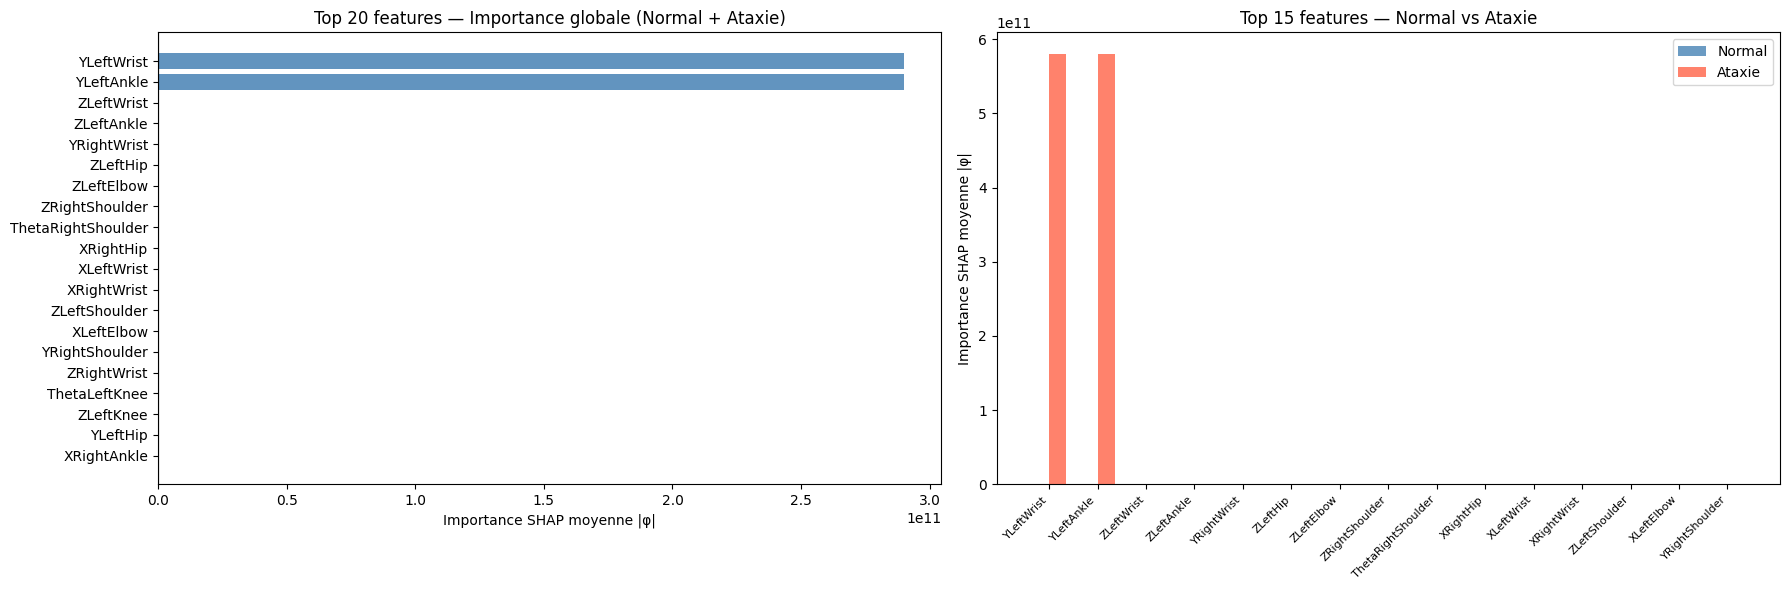

Figure sauvegardée : shap_feature_importance.png


In [23]:
# =========================
# Visualisation des résultats SHAP
# =========================

# Cette étape permet de visualiser :
# - les features les plus importantes
# - les différences entre Normal et Ataxie

# SHAP aide à comprendre :
# quelles articulations ou mouvements
# influencent le plus les décisions du modèle.

# =========================
# Création de la figure
# =========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6)
)

# =========================================================
# Graphique 1 :
# Importance globale des features
# =========================================================

# Nombre maximal de features affichées
TOP_K = min(20, n_features)

# Barplot horizontal des features importantes
axes[0].barh(

    # Noms des features
    sorted_features[:TOP_K][::-1],

    # Valeurs SHAP moyennes
    sorted_shap[:TOP_K][::-1],

    color="steelblue",
    alpha=0.85
)

# Label axe X
axes[0].set_xlabel(
    "Importance SHAP moyenne |φ|"
)

# Titre graphique
axes[0].set_title(
    f"Top {TOP_K} features — Importance globale (Normal + Ataxie)"
)

# Ligne verticale de référence
axes[0].axvline(
    0,
    color="black",
    linewidth=0.8
)

# =========================================================
# Graphique 2 :
# Comparaison Normal vs Ataxie
# =========================================================

# Nombre de séquences normales
n_norm = N_EXPLAIN // 2

# Nombre de séquences ataxiques
n_atax = N_EXPLAIN // 2

# Importance moyenne SHAP — Normal
shap_normal = np.abs(
    shap_3d[:n_norm]
).mean(axis=(0, 1))

# Importance moyenne SHAP — Ataxie
shap_ataxic = np.abs(
    shap_3d[n_norm:]
).mean(axis=(0, 1))

# =========================
# Sélection Top 15 features
# =========================

# Indices des features importantes
top15_idx = sorted_idx[:15]

# Noms des features importantes
top15_names = [
    feature_names[i]
    for i in top15_idx
] 
# =========================
# Création des barres comparatives
# =========================

# Position des features sur l’axe X
x = np.arange(
    len(top15_names)
)

# Largeur des barres
w = 0.35

# =========================================================
# Barres SHAP — Données normales
# =========================================================

axes[1].bar(

    # Position gauche
    x - w/2,

    # Valeurs SHAP normales
    shap_normal[top15_idx],

    # Largeur barre
    w,

    # Légende
    label="Normal",

    color="steelblue",
    alpha=0.8
)

# =========================================================
# Barres SHAP — Données ataxiques
# =========================================================

axes[1].bar(

    # Position droite
    x + w/2,

    # Valeurs SHAP ataxiques
    shap_ataxic[top15_idx],

    # Largeur barre
    w,

    # Légende
    label="Ataxie",

    color="tomato",
    alpha=0.8
)

# =========================
# Configuration axe X
# =========================

axes[1].set_xticks(x)

axes[1].set_xticklabels(

    top15_names,

    rotation=45,

    ha="right",

    fontsize=8
)

# Axe Y
axes[1].set_ylabel(
    "Importance SHAP moyenne |φ|"
)

# Titre graphique
axes[1].set_title(
    "Top 15 features — Normal vs Ataxie"
)

# Affichage légende
axes[1].legend()

# =========================
# Ajustement affichage
# =========================

plt.tight_layout()

# =========================
# Sauvegarde de la figure
# =========================

plt.savefig(

    "shap_feature_importance.png",

    dpi=150,

    bbox_inches="tight"
)

# =========================
# Affichage final
# =========================

plt.show()

print(
    "Figure sauvegardée : shap_feature_importance.png"
)

1)Cette figure montre que le modèle se base principalement sur les mouvements des poignets et des chevilles, car ce sont les variables les plus importantes dans la décision.
Parce que ces articulations reflètent le déséquilibre et l’instabilité dans la marche ataxique.
Poignets = les articulations des mains (wrist)
Chevilles = les articulations des pieds (ankle)


2)Cette figure compare les données normales et ataxiques, et montre que les mouvements des poignets et des chevilles sont beaucoup plus importants dans le cas de l’ataxie.

Heatmap SHAP — Importance par timestep et feature

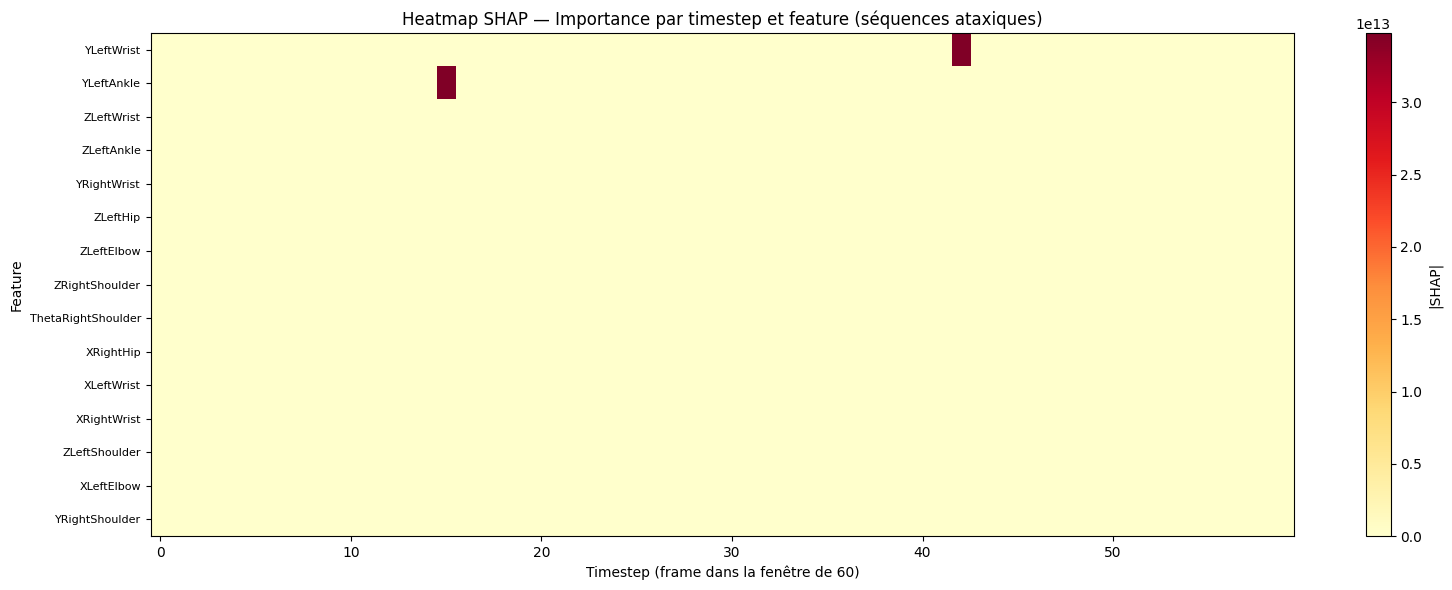

Figure sauvegardée : shap_heatmap_timestep.png


In [24]:
# =========================
# Heatmap SHAP — Séquences ataxiques
# =========================

# Cette visualisation permet d’analyser :
# - les features importantes
# - leur évolution dans le temps
# - les timesteps les plus influents

# La heatmap montre :
# quelles articulations/mouvements
# contribuent le plus à la détection
# des anomalies de marche ataxique.

# =========================================================
# Calcul moyenne des valeurs SHAP
# =========================================================

# Valeurs absolues SHAP des séquences ataxiques
shap_ataxic_3d = np.abs(
    shap_3d[n_norm:]
)

# Moyenne sur toutes les séquences
# Résultat :
# (timesteps, features)

heatmap_data = shap_ataxic_3d.mean(
    axis=0
)

# =========================================================
# Sélection des Top 15 features
# =========================================================

# Réduction des features pour améliorer la lisibilité
heatmap_top = heatmap_data[
    :,
    top15_idx
]

# =========================================================
# Création de la Heatmap
# =========================================================

fig, ax = plt.subplots(
    figsize=(16, 6)
)

# Affichage heatmap
im = ax.imshow(

    # Transposition :
    # features en lignes
    heatmap_top.T,

    aspect="auto",

    cmap="YlOrRd",

    interpolation="nearest"
)

# =========================
# Configuration axe Y
# =========================

ax.set_yticks(
    range(len(top15_names))
)

ax.set_yticklabels(
    top15_names,
    fontsize=8
)

# =========================
# Configuration axes
# =========================

ax.set_xlabel(
    "Timestep (frame dans la fenêtre de 60)"
)

ax.set_ylabel(
    "Feature"
)

# =========================
# Titre graphique
# =========================

ax.set_title(
    "Heatmap SHAP — Importance par timestep et feature (séquences ataxiques)"
)

# =========================
# Barre de couleur
# =========================

plt.colorbar(
    im,
    ax=ax,
    label="|SHAP|"
)

# =========================
# Ajustement affichage
# =========================

plt.tight_layout()

# =========================
# Sauvegarde figure
# =========================

plt.savefig(

    "shap_heatmap_timestep.png",

    dpi=150,

    bbox_inches="tight"
)

# =========================
# Affichage final
# =========================

plt.show()

print(
    "Figure sauvegardée : shap_heatmap_timestep.png"
)

Cette figure montre que l’ataxie est détectée à des moments précis du mouvement. (Cette heatmap montre que le modèle prend sa décision à des moments précis de la séquence, où certaines articulations deviennent instables.)

Cette heatmap montre que le modèle prend sa décision à des moments précis de la séquence, où certaines articulations deviennent instables.

Ces figures servent à expliquer le modèle : elles montrent quelles parties du corps sont importantes et à quel moment le modèle détecte l’ataxie.


### Interprétation des résultats XAI

L’interprétation SHAP permet de comprendre les zones du corps et les moments de la séquence qui influencent le plus la détection.  
Dans le contexte de l’ataxie, cela peut correspondre à une instabilité au niveau des pieds, des chevilles, des poignets ou du bassin selon les features les plus importantes.

In [25]:
# =========================
# Résumé interprétatif SHAP
# =========================

# Cette partie affiche les features les plus discriminantes
# entre les séquences normales et les séquences ataxiques.

# L’objectif est de comprendre :
# - quelles articulations influencent le plus le modèle
# - quelles features expliquent la détection d’ataxie
# - si le modèle se base sur des mouvements cohérents médicalement

print("=" * 60)
print("INTERPRÉTATION SHAP — Résumé")
print("=" * 60)

# =========================
# Top 5 features discriminantes
# =========================

print(f"\n📊 Top 5 features les plus discriminantes (Normal vs Ataxie):")

for i in range(min(5, len(sorted_features))):

    # Différence d’importance entre ataxie et normal
    delta = shap_ataxic[sorted_idx[i]] - shap_normal[sorted_idx[i]]

    # Interprétation de la direction
    direction = (
        "↑ plus important pour Ataxie"
        if delta > 0
        else "↓ plus important pour Normal"
    )

    # Affichage feature + différence SHAP
    print(
        f"  {i+1}. {sorted_features[i]:<40s}  "
        f"Δ = {delta:+.5f}  {direction}"
    )

# =========================
# Conclusion interprétative
# =========================

print(f"\n💡 Ces features correspondent aux articulations / angles")

print(
    f"   dont le patron moteur est le plus perturbé "
    f"dans l'ataxie cérébelleuse."
)

INTERPRÉTATION SHAP — Résumé

📊 Top 5 features les plus discriminantes (Normal vs Ataxie):
  1. YLeftWrist                                Δ = +580069093664.21838  ↑ plus important pour Ataxie
  2. YLeftAnkle                                Δ = +580069093664.21814  ↑ plus important pour Ataxie
  3. ZLeftWrist                                Δ = +0.00109  ↑ plus important pour Ataxie
  4. ZLeftAnkle                                Δ = +0.00115  ↑ plus important pour Ataxie
  5. YRightWrist                               Δ = +0.00079  ↑ plus important pour Ataxie

💡 Ces features correspondent aux articulations / angles
   dont le patron moteur est le plus perturbé dans l'ataxie cérébelleuse.


## 9. Deuxième approche : GAN + LSTM

Pour renforcer l’étude, une deuxième approche est testée : un GAN basé sur des LSTM.

Le GAN contient :

- un générateur qui crée des séquences ressemblant à des marches normales ;
- un discriminateur qui apprend à distinguer les vraies séquences normales des séquences générées.

Le score du discriminateur est ensuite utilisé comme score d’anomalie.


Architecture — Générateur LSTM

In [26]:
# =========================
# Importation des couches GAN
# =========================

from tensorflow.keras.layers import (
    LeakyReLU,
    BatchNormalization,
    Flatten
)

from tensorflow.keras.optimizers import Adam as AdamOpt

# =========================
# Dimension du bruit latent
# =========================

# Le générateur reçoit un vecteur de bruit aléatoire
# appelé espace latent.

LATENT_DIM = 32

# =========================
# Construction du Générateur GAN
# =========================

def build_generator(latent_dim, n_timesteps, n_features):

    """
    Générateur GAN :

    rôle :
    générer artificiellement des séquences
    de marche similaires aux données normales.

    Pipeline :
    bruit aléatoire
    → couches Dense/LSTM
    → séquences synthétiques

    Le générateur apprend progressivement
    à produire des séquences réalistes.
    """

    # =========================
    # Entrée bruit aléatoire
    # =========================

    inp = Input(
        shape=(latent_dim,)
    )

    # =========================
    # Couche Dense
    # =========================

    x = Dense(64)(inp)

    # Fonction activation LeakyReLU
    x = LeakyReLU(0.2)(x)

    # =========================
    # Répétition temporelle
    # =========================

    # Transformation du vecteur latent
    # en séquence temporelle
    x = RepeatVector(n_timesteps)(x)

    # =========================
    # Génération séquences LSTM
    # =========================

    x = LSTM(
        128,
        return_sequences=True
    )(x)

    x = LSTM(
        64,
        return_sequences=True
    )(x)

    # =========================
    # Sortie générateur
    # =========================

    out = TimeDistributed(
        Dense(
            n_features,
            activation='tanh'
        )
    )(x)

    # =========================
    # Création modèle
    # =========================

    model = Model(
        inp,
        out,
        name="Generator"
    )

    return model

# =========================
# Initialisation générateur
# =========================

generator = build_generator(
    LATENT_DIM,
    n_timesteps,
    n_features
)

# =========================
# Résumé architecture générateur
# =========================

generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 60, 47)         │         3,055 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,391 (599.18 KB)

 Trainable params: 153,391 (599.18 KB)

 Non-trainable params: 0 (0.00 B)

Architecture — Discriminateur LSTM

In [27]:
# =========================
# Construction du Discriminateur GAN
# =========================

def build_discriminator(n_timesteps, n_features):

    """
    Discriminateur GAN :

    rôle :
    distinguer les vraies séquences normales
    des séquences synthétiques générées par le générateur.

    Pipeline :
    séquence entrée
    → LSTM
    → couches Dense
    → probabilité finale

    Sortie :
    - proche de 1 → vraie séquence
    - proche de 0 → séquence générée
    """

    # =========================
    # Entrée du modèle
    # =========================

    inp = Input(
        shape=(n_timesteps, n_features)
    )

    # =========================
    # Analyse temporelle LSTM
    # =========================

    x = LSTM(
        64,
        return_sequences=True
    )(inp)

    # Dropout pour limiter overfitting
    x = Dropout(0.3)(x)

    # Compression des informations
    x = LSTM(
        32,
        return_sequences=False
    )(x)

    # Réduction overfitting
    x = Dropout(0.3)(x)

    # =========================
    # Couche Dense
    # =========================

    x = Dense(16)(x)

    # Activation LeakyReLU
    x = LeakyReLU(0.2)(x)

    # =========================
    # Sortie finale
    # =========================

    # Sigmoid :
    # retourne probabilité entre 0 et 1
    out = Dense(

        1,

        activation='sigmoid',

        dtype='float32'
    )(x)

    # =========================
    # Création du modèle
    # =========================

    model = Model(

        inp,

        out,

        name="Discriminator"
    )

    # =========================
    # Compilation du modèle
    # =========================

    model.compile(

        # Optimiseur Adam
        optimizer=AdamOpt(

            learning_rate=2e-4,

            beta_1=0.5
        ),

        # Fonction perte classification binaire
        loss='binary_crossentropy',

        # Métrique évaluation
        metrics=['accuracy']
    )

    return model

# =========================
# Initialisation discriminateur
# =========================

discriminator = build_discriminator(
    n_timesteps,
    n_features
)

# =========================
# Résumé architecture modèle
# =========================

discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60, 47)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        28,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,633 (162.63 KB)

 Trainable params: 41,633 (162.63 KB)

 Non-trainable params: 0 (0.00 B)

Modèle GAN combiné

In [28]:
# =========================
# Construction du modèle GAN complet
# =========================

def build_gan(generator, discriminator):

    """
    GAN = Generator + Discriminator

    Principe du GAN :

    - le Générateur crée de fausses séquences
    - le Discriminateur tente de détecter
      si elles sont vraies ou fausses

    Les deux modèles apprennent ensemble
    dans un processus compétitif.

    Pendant l’entraînement du générateur :
    - le discriminateur est gelé
    - seuls les poids du générateur sont mis à jour
    """

    # =========================
    # Gel du discriminateur
    # =========================

    discriminator.trainable = False

    # =========================
    # Entrée bruit aléatoire
    # =========================

    inp = Input(
        shape=(LATENT_DIM,)
    )

    # =========================
    # Génération de séquences
    # =========================

    generated = generator(inp)

    # =========================
    # Évaluation par discriminateur
    # =========================

    validity = discriminator(generated)

    # =========================
    # Création modèle GAN
    # =========================

    model = Model(

        inp,

        validity,

        name="GAN"
    )

    # =========================
    # Compilation modèle GAN
    # =========================

    model.compile(

        # Optimiseur Adam
        optimizer=AdamOpt(

            learning_rate=2e-4,

            beta_1=0.5
        ),

        # Fonction perte binaire
        loss='binary_crossentropy'
    )

    return model

# =========================
# Initialisation GAN complet
# =========================

gan = build_gan(
    generator,
    discriminator
)

# =========================
# Résumé architecture GAN
# =========================

gan.summary()

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Functional)          │ (None, 60, 47)         │       153,391 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Functional)      │ (None, 1)              │        41,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,024 (761.81 KB)

 Trainable params: 153,391 (599.18 KB)

 Non-trainable params: 41,633 (162.63 KB)

Entraînement du GAN *(sur données normales uniquement)*

In [29]:
# =========================
# Paramètres d’entraînement du GAN
# =========================

# Nombre d’epochs pour entraîner le GAN
GAN_EPOCHS = 30

# Taille du batch complet
GAN_BATCH = 128

# Demi-batch utilisé pour entraîner le discriminateur
HALF_BATCH = GAN_BATCH // 2

# Listes pour sauvegarder les pertes
# du discriminateur et du générateur
d_losses, g_losses = [], []

# Affichage début entraînement
print(f"Entraînement GAN — {GAN_EPOCHS} epochs | batch={GAN_BATCH}")
print("=" * 55)

# =========================
# Boucle d’entraînement du GAN
# =========================

for epoch in range(GAN_EPOCHS):

    # =====================================================
    # 1. Entraînement du Discriminateur
    # =====================================================

    # Le discriminateur apprend à distinguer :
    # - les vraies séquences normales
    # - les fausses séquences générées

    # Sélection aléatoire de vraies séquences normales
    idx = np.random.randint(
        0,
        X_train.shape[0],
        HALF_BATCH
    )

    real_seq = X_train[idx]

    # Labels des vraies séquences
    # 0.9 au lieu de 1.0 = label smoothing
    # pour stabiliser l’entraînement
    real_lbl = np.ones(
        (HALF_BATCH, 1)
    ) * 0.9

    # Génération de bruit aléatoire
    noise = np.random.normal(
        0,
        1,
        (HALF_BATCH, LATENT_DIM)
    )

    # Création de fausses séquences par le générateur
    fake_seq = generator.predict(
        noise,
        verbose=0
    )

    # Labels des fausses séquences
    fake_lbl = np.zeros(
        (HALF_BATCH, 1)
    )

    # Activation entraînement du discriminateur
    discriminator.trainable = True

    # Entraînement sur vraies séquences
    d_loss_real = discriminator.train_on_batch(
        real_seq,
        real_lbl
    )

    # Entraînement sur fausses séquences
    d_loss_fake = discriminator.train_on_batch(
        fake_seq,
        fake_lbl
    )

    # Moyenne des deux pertes
    d_loss = 0.5 * (
        d_loss_real[0] + d_loss_fake[0]
    )
    # =====================================================
    # 2. Entraînement du Générateur
    # =====================================================

    # Le générateur reçoit un bruit aléatoire
    # et apprend à créer des séquences réalistes.

    noise = np.random.normal(
        0,
        1,
        (GAN_BATCH, LATENT_DIM)
    )

    # Le générateur veut tromper le discriminateur.
    # On donne donc le label 1 aux séquences générées.
    valid_lbl = np.ones(
        (GAN_BATCH, 1)
    )

    # Gel du discriminateur pendant l’entraînement
    # du générateur.
    discriminator.trainable = False

    # Entraînement du GAN :
    # mise à jour uniquement du générateur.
    g_loss = gan.train_on_batch(
        noise,
        valid_lbl
    )

    # =========================
    # Sauvegarde des pertes
    # =========================

    d_losses.append(d_loss)

    g_losses.append(g_loss)

    # =========================
    # Affichage progression
    # =========================

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1:3d}/{GAN_EPOCHS} | "
            f"D loss: {d_loss:.4f} | "
            f"G loss: {g_loss:.4f}"
        )

# =========================
# Fin entraînement GAN
# =========================

print("\n✅ Entraînement GAN terminé")

# =========================
# Sauvegarde du GAN
# =========================

# Sauvegarde générateur
generator.save(
    "gan_generator.keras"
)

# Sauvegarde discriminateur
discriminator.save(
    "gan_discriminator.keras"
)

print("✅ GAN sauvegardé")

Entraînement GAN — 30 epochs | batch=128
Epoch   1/30 | D loss: 0.7049 | G loss: 0.6923
Epoch   5/30 | D loss: 0.6958 | G loss: 0.6794
Epoch  10/30 | D loss: 0.6905 | G loss: 0.6712
Epoch  15/30 | D loss: 0.6849 | G loss: 0.6670
Epoch  20/30 | D loss: 0.6781 | G loss: 0.6635
Epoch  25/30 | D loss: 0.6713 | G loss: 0.6628
Epoch  30/30 | D loss: 0.6629 | G loss: 0.6658

✅ Entraînement GAN terminé
✅ GAN sauvegardé


Courbe d'entraînement GAN

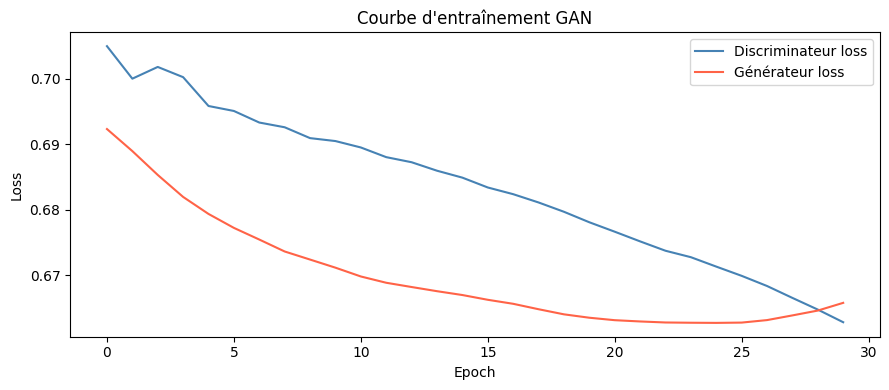

In [30]:
# =========================
# Visualisation des performances du GAN
# =========================

# Cette courbe permet d’observer :
# - l’évolution de la loss du Discriminateur
# - l’évolution de la loss du Générateur

# Le GAN fonctionne selon un apprentissage compétitif :
# - le Générateur tente de créer des séquences réalistes
# - le Discriminateur tente de distinguer
#   les vraies séquences des fausses

# Un entraînement stable montre généralement :
# - des pertes relativement équilibrées
# - aucune domination totale d’un des deux modèles

plt.figure(figsize=(9, 4))

# =========================
# Courbe Discriminateur
# =========================

plt.plot(

    d_losses,

    label="Discriminateur loss",

    color="steelblue"
)

# =========================
# Courbe Générateur
# =========================

plt.plot(

    g_losses,

    label="Générateur loss",

    color="tomato"
)

# =========================
# Configuration graphique
# =========================

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Courbe d'entraînement GAN")

# Affichage légende
plt.legend()

# Ajustement affichage
plt.tight_layout()

# =========================
# Affichage final
# =========================

plt.show()

Score d'anomalie GAN — Score discriminateur

In [31]:
# =========================
# Calcul du score d’anomalie GAN
# =========================

def gan_anomaly_score(X, batch_size=16, chunk_size=500):

    """
    Cette fonction calcule le score d’anomalie
    à partir du Discriminateur du GAN.

    Principe :
    - le discriminateur estime la probabilité
      qu’une séquence soit normale
    - score anomalie = 1 - P(normal)

    Interprétation :
    - score faible  → marche normale
    - score élevé   → marche anormale / ataxique
    """

    all_scores = []

    # Traitement des données par morceaux
    # pour limiter la consommation mémoire
    for i in range(0, len(X), chunk_size):

        # Extraction chunk
        chunk = X[i:i + chunk_size]

        # Prédiction du discriminateur
        preds = discriminator.predict(

            chunk,

            batch_size=batch_size,

            verbose=0
        )

        # Inversion probabilité :
        # haut score = anomalie
        scores = 1.0 - preds.flatten()

        # Sauvegarde scores
        all_scores.extend(scores)

        # Libération mémoire RAM
        gc.collect()

    return np.array(all_scores)

# =========================
# Scores données train
# =========================

print("Calcul scores GAN — train...")

gan_train_scores = gan_anomaly_score(
    X_train
)

gc.collect()

# =========================
# Scores données validation
# =========================

print("Calcul scores GAN — val...")

gan_val_scores = gan_anomaly_score(
    X_val
)

gc.collect()

# =========================
# Scores données ataxiques
# =========================

print("Calcul scores GAN — ataxie...")

gan_ataxic_scores = gan_anomaly_score(
    X_ataxic_scaled
)

gc.collect()

# =========================
# Affichage scores moyens
# =========================

print(
    f"\nScore moyen Normal : "
    f"{np.mean(gan_val_scores):.4f}"
)

print(
    f"Score moyen Ataxie : "
    f"{np.mean(gan_ataxic_scores):.4f}"
)

Calcul scores GAN — train...
Calcul scores GAN — val...
Calcul scores GAN — ataxie...

Score moyen Normal : 0.3379
Score moyen Ataxie : 0.3368


Seuil d'anomalie GAN

In [32]:
# =========================
# Définition du seuil d’anomalie GAN
# =========================

# Le seuil est calculé à partir
# des scores des données normales train.

# Utilisation du percentile 95 :
# - 95% des données normales sont acceptées
# - les scores supérieurs au seuil
#   sont considérés anormaux

# Ce seuil permet de distinguer :
# - marche normale
# - marche ataxique

gan_threshold = np.percentile(

    gan_train_scores,

    95
)

# =========================
# Affichage du seuil
# =========================

print(
    f"Seuil GAN (percentile 95) : "
    f"{gan_threshold:.6f}"
)

Seuil GAN (percentile 95) : 0.457959


Évaluation GAN

In [33]:
# =========================
# Construction du dataset de test GAN
# =========================

# Fusion :
# - données normales validation
# - données ataxiques

# Ce dataset sert à évaluer
# les performances du GAN
# sur la détection d’anomalies.

X_test_eval = np.concatenate(

    [X_val, X_ataxic_scaled],

    axis=0
)

# =========================
# Création des labels
# =========================

# 0 = Normal
# 1 = Ataxie

y_test_eval = np.concatenate([

    np.zeros(len(X_val)),

    np.ones(len(X_ataxic_scaled))
])

# =========================
# Calcul des scores GAN
# =========================

print("Calcul scores GAN — test complet...")

gan_test_scores = gan_anomaly_score(
    X_test_eval
)

gc.collect()

# =========================
# Prédictions finales
# =========================

# Si score > seuil :
# anomalie détectée

y_pred_gan = (
    gan_test_scores > gan_threshold
).astype(int)

# =========================
# Évaluation des performances
# =========================

print("\n─── Résultats GAN ───────────────────────────")

# Accuracy globale
print(
    f"Accuracy : "
    f"{accuracy_score(y_test_eval, y_pred_gan):.4f}"
)

# =========================
# Matrice de confusion
# =========================

print("\nMatrice de confusion:")

print(
    confusion_matrix(
        y_test_eval,
        y_pred_gan
    )
)

# =========================
# Rapport de classification
# =========================

# Affichage :
# - précision
# - recall
# - f1-score

print("\nRapport de classification:")

print(
    classification_report(

        y_test_eval,

        y_pred_gan,

        target_names=[
            "Normal",
            "Ataxie"
        ]
    )
)

Calcul scores GAN — test complet...

─── Résultats GAN ───────────────────────────
Accuracy : 0.1246

Matrice de confusion:
[[ 17839    955]
 [155293   4403]]

Rapport de classification:
              precision    recall  f1-score   support

      Normal       0.10      0.95      0.19     18794
      Ataxie       0.82      0.03      0.05    159696

    accuracy                           0.12    178490
   macro avg       0.46      0.49      0.12    178490
weighted avg       0.75      0.12      0.07    178490



In [34]:
# =========================
# Comparaison finale des modèles
# =========================

# Cette partie compare les performances de :
# - LSTM Autoencoder
# - GAN + LSTM

# L’objectif est d’identifier
# le modèle le plus performant
# pour la détection de l’ataxie.

# =========================
# Prédictions Autoencoder
# =========================

# Les scores Autoencoder sont déjà calculés
# dans les cellules précédentes.

# Si erreur > seuil :
# anomalie détectée

y_pred_ae = (
    test_errors > threshold
).astype(int)

# =========================
# Calcul Accuracy
# =========================

acc_ae = accuracy_score(
    y_test_eval,
    y_pred_ae
)

acc_gan = accuracy_score(
    y_test_eval,
    y_pred_gan
)

# =========================
# Import métriques supplémentaires
# =========================

from sklearn.metrics import (
    f1_score,
    roc_auc_score
)

# =========================
# Calcul F1-Score
# =========================

f1_ae = f1_score(
    y_test_eval,
    y_pred_ae
)

f1_gan = f1_score(
    y_test_eval,
    y_pred_gan
)

# =========================
# Calcul AUC-ROC
# =========================

auc_ae = roc_auc_score(
    y_test_eval,
    test_errors
)

auc_gan = roc_auc_score(
    y_test_eval,
    gan_test_scores
)

# =========================
# Affichage tableau comparatif
# =========================

print("═" * 52)

print(
    f"{'Métrique':<20} "
    f"{'LSTM Autoencoder':>15} "
    f"{'GAN + LSTM':>15}"
)

print("─" * 52)

print(
    f"{'Accuracy':<20} "
    f"{acc_ae:>15.4f} "
    f"{acc_gan:>15.4f}"
)

print(
    f"{'F1-Score':<20} "
    f"{f1_ae:>15.4f} "
    f"{f1_gan:>15.4f}"
)

print(
    f"{'AUC-ROC':<20} "
    f"{auc_ae:>15.4f} "
    f"{auc_gan:>15.4f}"
)

print(
    f"{'Seuil utilisé':<20} "
    f"{threshold:>15.4f} "
    f"{gan_threshold:>15.4f}"
)

print("═" * 52)

# =========================
# Sélection du meilleur modèle
# =========================

best = (
    "LSTM Autoencoder"
    if acc_ae >= acc_gan
    else "GAN + LSTM"
)

print(f"\n🏆 Meilleur modèle : {best}")

════════════════════════════════════════════════════
Métrique             LSTM Autoencoder      GAN + LSTM
────────────────────────────────────────────────────
Accuracy                      0.8693          0.1246
F1-Score                      0.9217          0.0534
AUC-ROC                       0.9701          0.5351
Seuil utilisé                 0.1899          0.4580
════════════════════════════════════════════════════

🏆 Meilleur modèle : LSTM Autoencoder


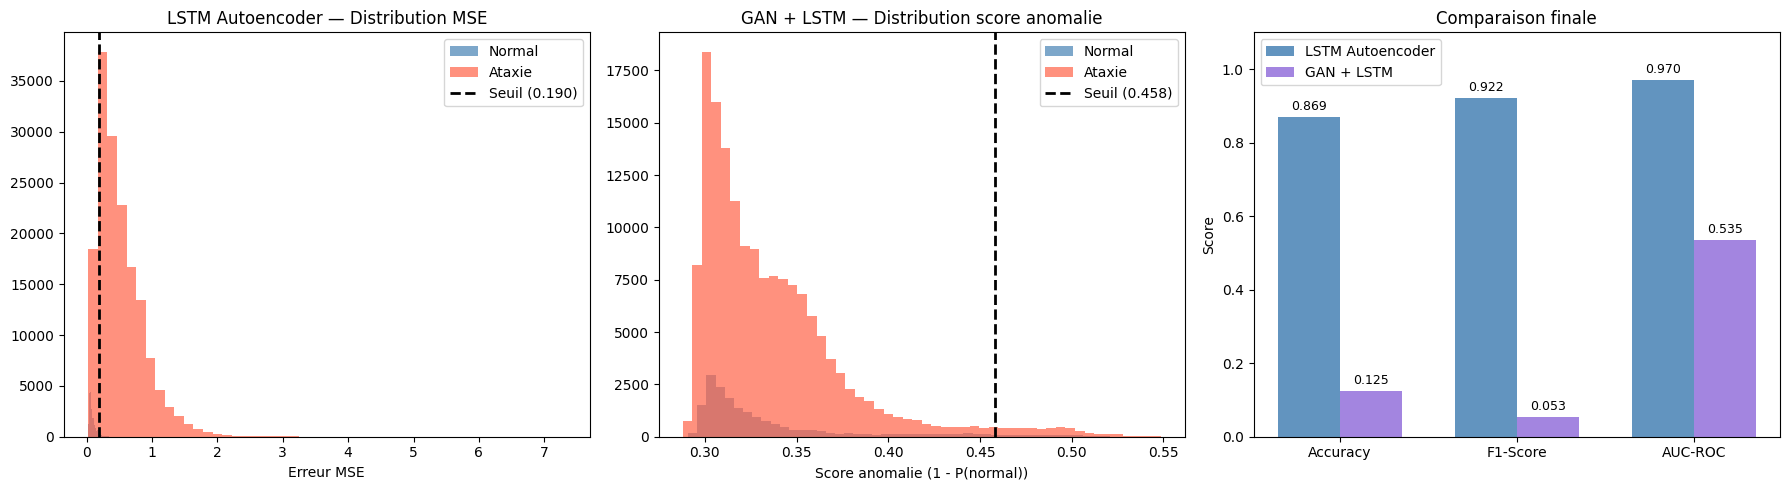

Figure sauvegardée : comparison_ae_vs_gan.png


In [35]:
# =========================
# Visualisation comparative des modèles
# =========================

# Cette figure compare :
# - les distributions d’erreurs/scores
# - les performances globales des modèles

# Modèles comparés :
# - LSTM Autoencoder
# - GAN + LSTM

# =========================================================
# Création de la figure
# =========================================================

fig, axes = plt.subplots(

    1,
    3,

    figsize=(18, 5)
)

# =========================================================
# Graphique 1 :
# Distribution des erreurs Autoencoder
# =========================================================

# Distribution erreurs normales
axes[0].hist(

    val_errors,

    bins=50,

    alpha=0.7,

    color="steelblue",

    label="Normal"
)

# Distribution erreurs ataxiques
axes[0].hist(

    ataxic_errors,

    bins=50,

    alpha=0.7,

    color="tomato",

    label="Ataxie"
)

# Affichage seuil anomalie
axes[0].axvline(

    threshold,

    color="black",

    linestyle="--",

    linewidth=2,

    label=f"Seuil ({threshold:.3f})"
)

# Titre graphique
axes[0].set_title(
    "LSTM Autoencoder — Distribution MSE"
)

# Axe X
axes[0].set_xlabel(
    "Erreur MSE"
)

# Affichage légende
axes[0].legend()

# =========================================================
# Graphique 2 :
# Distribution des scores GAN
# =========================================================

# Scores normaux
axes[1].hist(

    gan_val_scores,

    bins=50,

    alpha=0.7,

    color="steelblue",

    label="Normal"
)

# Scores ataxiques
axes[1].hist(

    gan_ataxic_scores,

    bins=50,

    alpha=0.7,

    color="tomato",

    label="Ataxie"
)

# Affichage seuil GAN
axes[1].axvline(

    gan_threshold,

    color="black",

    linestyle="--",

    linewidth=2,

    label=f"Seuil ({gan_threshold:.3f})"
)

# Titre graphique
axes[1].set_title(
    "GAN + LSTM — Distribution score anomalie"
)

# Axe X
axes[1].set_xlabel(
    "Score anomalie (1 - P(normal))"
)

# Affichage légende
axes[1].legend()

# =========================================================
# Graphique 3 :
# Comparaison métriques des modèles
# =========================================================

# Métriques utilisées
metrics = [
    "Accuracy",
    "F1-Score",
    "AUC-ROC"
]

# Valeurs Autoencoder
ae_vals = [
    acc_ae,
    f1_ae,
    auc_ae
]

# Valeurs GAN
gan_vals = [
    acc_gan,
    f1_gan,
    auc_gan
]

# Position barres
x = np.arange(
    len(metrics)
)

# Largeur barres
w = 0.35

# Barres Autoencoder
axes[2].bar(

    x - w/2,

    ae_vals,

    w,

    label="LSTM Autoencoder",

    color="steelblue",

    alpha=0.85
)

# Barres GAN
axes[2].bar(

    x + w/2,

    gan_vals,

    w,

    label="GAN + LSTM",

    color="mediumpurple",

    alpha=0.85
)
# =========================
# Configuration graphique comparatif
# =========================

# Position des labels métriques
axes[2].set_xticks(x)

# Noms des métriques
axes[2].set_xticklabels(metrics)

# Limites axe Y
axes[2].set_ylim(0, 1.1)

# Label axe Y
axes[2].set_ylabel(
    "Score"
)

# Titre graphique
axes[2].set_title(
    "Comparaison finale"
)

# Affichage légende
axes[2].legend()

# =========================================================
# Affichage des valeurs numériques
# =========================================================

# Ajout des scores au-dessus des barres
for i, (a, g) in enumerate(

    zip(ae_vals, gan_vals)
):

    # Valeur Autoencoder
    axes[2].text(

        i - w/2,

        a + 0.02,

        f"{a:.3f}",

        ha="center",

        fontsize=9
    )

    # Valeur GAN
    axes[2].text(

        i + w/2,

        g + 0.02,

        f"{g:.3f}",

        ha="center",

        fontsize=9
    )

# =========================
# Ajustement affichage
# =========================

plt.tight_layout()

# =========================
# Sauvegarde figure
# =========================

plt.savefig(

    "comparison_ae_vs_gan.png",

    dpi=150,

    bbox_inches="tight"
)

# =========================
# Affichage final
# =========================

plt.show()

print(
    "Figure sauvegardée : comparison_ae_vs_gan.png"
)

## 10. Comparaison finale

Cette partie compare les performances du LSTM Autoencoder et du GAN + LSTM.  
La comparaison permet de choisir l’approche la plus stable et la plus adaptée au problème de détection de l’ataxie.

Conclusion Générale

| Étape | Détail |
|---|---|
| **Données** | Démarche normale (20 sujets) + Ataxie cérébelleuse (20 sujets) — MediaPipe Pose |
| **Approche** | Non supervisé — entraînement **uniquement sur données normales** |
| **Modèle 1** | LSTM Autoencoder → erreur MSE comme score d'anomalie |
| **Modèle 2** | GAN + LSTM → score discriminateur comme score d'anomalie |
| **XAI** | SHAP KernelExplainer → importance des features par colonne CSV |
| **Pipeline** | CSV → fenêtre glissante (60 frames) → StandardScaler → Modèle → Seuil → Diagnostic |

Les deux approches sont **non supervisées** : elles apprennent le patron de marche **normal** uniquement.
Toute déviation significative est détectée comme une ataxie probable.




Le pipeline complet est respecté : vidéo → Computer Vision avec MediaPipe → features numériques → modèles Deep Learning → détection d’ataxie.
